# KKBox Churn Prediction — EDA

## Data dictionary

Source: KKBox WSDM 2017 churn challenge. Raw `.7z` archives are ETL'd into `data/processed/*.parquet` by `00_data_processing.ipynb`.

**`members`** — 6,769,473 rows, one row per user
| Column | Type | Description |
|---|---|---|
| `msno` | string | user ID (hashed) |
| `city` | int8 | city code |
| `bd` | int16 | age (self-reported; contains outliers/nonsense values) |
| `gender` | category | `male` / `female` / missing |
| `registered_via` | int8 | registration method code |
| `registration_init_time` | int32 | registration date, `YYYYMMDD` int |

**`transactions` / `transactions_v2`** — 21.5M / 1.4M rows, one row per transaction
| Column | Type | Description |
|---|---|---|
| `msno` | string | user ID |
| `payment_method_id` | int8 | payment method code |
| `payment_plan_days` | int16 | length of membership plan in days |
| `plan_list_price` | int16 | listed price (TWD) |
| `actual_amount_paid` | int32 | amount actually paid (TWD) |
| `is_auto_renew` | int8 | 1 = auto-renew enabled |
| `transaction_date` | int32 | date of transaction, `YYYYMMDD` |
| `membership_expire_date` | int32 | resulting membership expiry date |
| `is_cancel` | int8 | 1 = user canceled on this transaction |

**`user_logs` / `user_logs_v2`** — 392M / 18.4M rows, daily listening behavior
| Column | Type | Description |
|---|---|---|
| `msno` | string | user ID |
| `date` | int32 | log date, `YYYYMMDD` |
| `num_25` | int32 | # songs played <25% of duration |
| `num_50` | int32 | # songs played 25–50% |
| `num_75` | int32 | # songs played 50–75% |
| `num_985` | int32 | # songs played 75–98.5% |
| `num_100` | int32 | # songs played ≥98.5% (near-complete) |
| `num_unq` | int32 | # unique songs played |
| `total_secs` | float | total seconds played |

**`train` / `train_v2`** — 992,931 / 970,960 rows, labels
| Column | Type | Description |
|---|---|---|
| `msno` | string | user ID |
| `is_churn` | int8 | 1 = churned (no renewal within 30 days of membership expiration) |

`_v2` files are a later Kaggle snapshot (different train/label period) used alongside the originals.

In [1]:
import os

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROCESSED_DIR = os.path.join(os.getcwd(), "data", "processed")
con = duckdb.connect()


def p(name):
    return os.path.join(PROCESSED_DIR, f"{name}.parquet")


sns.set_theme(style="whitegrid")

## Dataset overview

In [2]:
for name in ["members", "train", "train_v2", "transactions", "transactions_v2", "user_logs_v2", "user_logs"]:
    n = con.execute(f"select count(*) from '{p(name)}'").fetchone()[0]
    print(f"{name:20s} {n:>15,} rows")

members                    6,769,473 rows
train                        992,931 rows
train_v2                     970,960 rows
transactions              21,547,746 rows
transactions_v2            1,431,009 rows
user_logs_v2              18,396,362 rows
user_logs                392,106,543 rows


## Churn label balance (`train_v2`)

,is_churn,n,pct
0,0,883630,91.005809
1,1,87330,8.994191


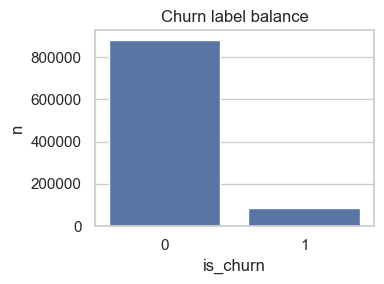

In [3]:
churn_balance = con.execute(f"select is_churn, count(*) n from '{p('train_v2')}' group by 1 order by 1").df()
churn_balance["pct"] = churn_balance["n"] / churn_balance["n"].sum() * 100
display(churn_balance)

fig, ax = plt.subplots(figsize=(4, 3))
sns.barplot(data=churn_balance, x="is_churn", y="n", ax=ax)
ax.set_title("Churn label balance")
fig.tight_layout()

This is the target we'd model. It's imbalanced: **~9% churn** vs ~91% retained, so downstream modeling should account for the imbalance (class weights, stratified sampling, metrics like AUC/PR-AUC).

> **Historical figure, superseded**: this ~9% is `train_v2`'s survivorship-biased snapshot rate (see project discussion / `02_Feature_Engineering.ipynb`). Kept here as-is for narrative continuity — see "Corrected churn rates" and "Survival analysis" below for the numbers actually used downstream (~74% in the modeling population).

## Member demographics

valid bd share: 32.8%


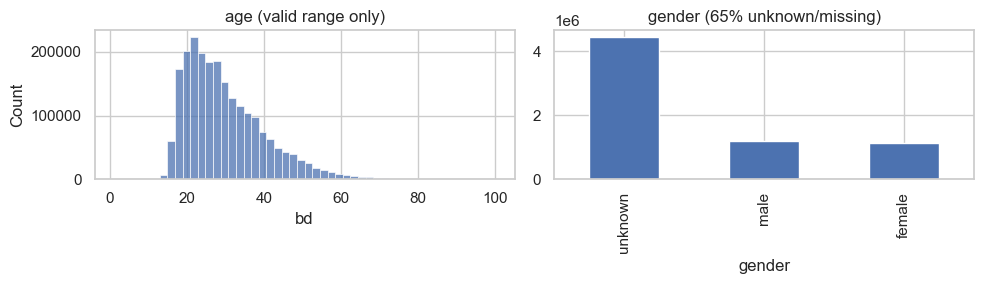

In [4]:
members = con.execute(f"select city, bd, gender, registered_via, registration_init_time from '{p('members')}'").df()
valid_bd = members[(members.bd > 0) & (members.bd <= 100)]
print(f"valid bd share: {len(valid_bd) / len(members) * 100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
sns.histplot(valid_bd["bd"], bins=50, ax=axes[0])
axes[0].set_title("age (valid range only)")
members["gender"].fillna("unknown").value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("gender (65% unknown/missing)")
fig.tight_layout()

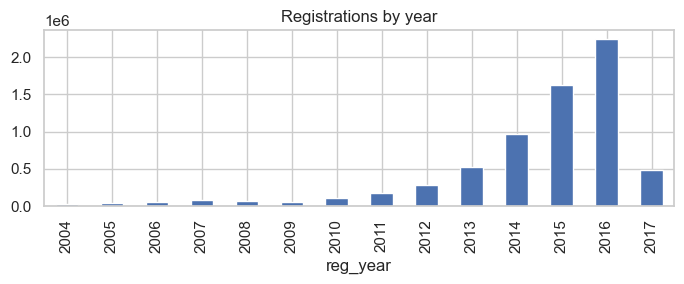

In [5]:
members["reg_year"] = members["registration_init_time"].astype(str).str[:4].astype(int)

fig, ax = plt.subplots(figsize=(7, 3))
members[members.reg_year.between(2004, 2017)]["reg_year"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Registrations by year")
fig.tight_layout()

`members` is small enough (6.8M rows) to load fully into pandas.

**Data quality issue:** `bd` (age) is self-reported and mostly garbage — only **~33%** of values fall in a plausible 1-100 range (min/max seen are -7168 and 2016). Any modeling use of age should filter to that range and treat the rest as missing.

## Churn rate by member attributes

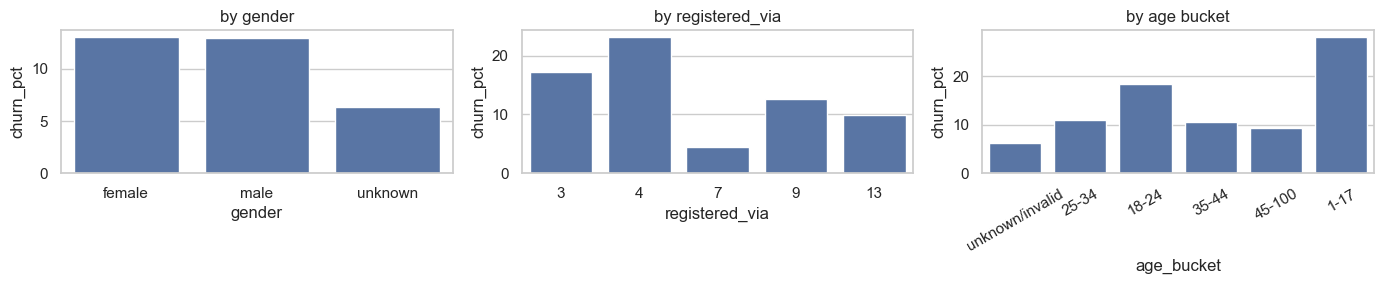

In [6]:
churn_by_gender = con.execute(f"""
    select coalesce(m.gender, 'unknown') gender, count(*) n, avg(t.is_churn) * 100 churn_pct
    from '{p('train_v2')}' t
    left join '{p('members')}' m using (msno)
    group by 1
""").df()

churn_by_registered_via = con.execute(f"""
    select m.registered_via, count(*) n, avg(t.is_churn) * 100 churn_pct
    from '{p('train_v2')}' t
    left join '{p('members')}' m using (msno)
    group by 1 order by n desc limit 8
""").df()

churn_by_age = con.execute(f"""
    select case when m.bd between 1 and 17 then '1-17'
                when m.bd between 18 and 24 then '18-24'
                when m.bd between 25 and 34 then '25-34'
                when m.bd between 35 and 44 then '35-44'
                when m.bd between 45 and 100 then '45-100'
                else 'unknown/invalid' end age_bucket,
           count(*) n, avg(t.is_churn) * 100 churn_pct
    from '{p('train_v2')}' t
    left join '{p('members')}' m using (msno)
    group by 1 order by n desc
""").df()

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
sns.barplot(data=churn_by_gender, x="gender", y="churn_pct", ax=axes[0])
sns.barplot(data=churn_by_registered_via, x="registered_via", y="churn_pct", ax=axes[1])
sns.barplot(data=churn_by_age, x="age_bucket", y="churn_pct", ax=axes[2])
axes[2].tick_params(axis="x", rotation=30)
for ax, title in zip(axes, ["by gender", "by registered_via", "by age bucket"]):
    ax.set_title(title)
fig.tight_layout()

Joining `train_v2` with `members`. Notable patterns:
- `registered_via` matters a lot: channel 4 churns at **23%**, channel 3 at **17%**, vs channel 7 at only **4.5%**.
- Users with missing gender/age (the majority) churn noticeably *less* (~6%) than users with a recorded gender/age (~13-18%) — the presence of profile data may itself be a signal of engagement, or these could be different user cohorts (e.g. signup era/channel).
- Among valid ages, the youngest bucket (1-17, mostly likely still low-quality data) has the highest churn (~28%), and 18-24 is also high (~18%).

> **Historical figure, superseded**: computed on `train_v2`'s survivorship-biased population. The *relative* ordering between segments (which group churns more) tends to be directionally similar in the corrected data, but the absolute percentages here are not — see "Corrected churn rates" below.

## Subscription / transaction behavior (`transactions_v2`)

,is_auto_renew,is_cancel,n,churn_pct
0,0,0,82918,30.579609
1,1,0,827985,1.765370
2,1,1,22675,79.038589


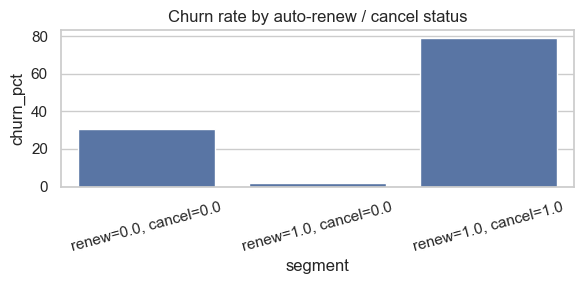

In [7]:
txn_behavior = con.execute(f"""
    with latest as (
        select *, row_number() over (partition by msno order by transaction_date desc) rn
        from '{p('transactions_v2')}'
    )
    select l.is_auto_renew, l.is_cancel, count(*) n, avg(t.is_churn) * 100 churn_pct
    from latest l
    join '{p('train_v2')}' t using (msno)
    where l.rn = 1
    group by 1, 2
    order by 1, 2
""").df()
display(txn_behavior)

txn_behavior["segment"] = txn_behavior.apply(lambda r: f"renew={r.is_auto_renew}, cancel={r.is_cancel}", axis=1)
fig, ax = plt.subplots(figsize=(6, 3))
sns.barplot(data=txn_behavior, x="segment", y="churn_pct", ax=ax)
ax.set_title("Churn rate by auto-renew / cancel status")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()

`transactions_v2` covers the same window as the `train_v2` labels. Taking each user's latest transaction and joining to churn shows the strongest signals in the whole dataset:
- **`is_auto_renew=0`**: 30.6% churn vs 1.8% for `is_auto_renew=1` — auto-renew is a very strong retention signal.
- **`is_cancel=1`**: 79.0% churn vs 4.4% for `is_cancel=0` — a cancellation almost always precedes churn (expected, borderline definitional — worth checking for label leakage if used directly as a model feature).
- Plans with `payment_plan_days > 90` churn at 90-99%, vs ~4.4% for the dominant 1-31 day plans — these longer/unusual plans are rare and behave very differently.

> **Historical figure, superseded**: computed on `train_v2`'s survivorship-biased population — see "Corrected churn rates" below for the same auto-renew/cancel breakdown on the corrected population.

## Listening behavior (`user_logs_v2`) vs churn

In [8]:
behavior_vs_churn = con.execute(f"""
    with agg as (
        select msno, count(distinct date) active_days, sum(total_secs) / 3600 total_hours, sum(num_unq) total_unq
        from '{p('user_logs_v2')}'
        group by msno
    )
    select t.is_churn, count(*) n, avg(a.active_days) avg_active_days,
           avg(a.total_hours) avg_total_hours, avg(a.total_unq) avg_unq_songs
    from '{p('train_v2')}' t
    left join agg a using (msno)
    group by 1
""").df()
display(behavior_vs_churn)

pct_no_activity = con.execute(f"""
    select avg(case when a.msno is null then 1 else 0 end) * 100
    from '{p('train_v2')}' t
    left join (select distinct msno from '{p('user_logs_v2')}') a using (msno)
""").fetchone()[0]
print(f"train_v2 users with zero user_logs_v2 rows: {pct_no_activity:.1f}%")

,is_churn,n,avg_active_days,avg_total_hours,avg_unq_songs
0,0,883630,18.134032,39.198078,515.732526
1,1,87330,15.914814,35.080897,472.744190


train_v2 users with zero user_logs_v2 rows: 22.3%


Aggregating daily logs per user over the `train_v2` window. Churned users show **modestly lower** engagement (18.1 vs 15.9 active days, 39.2 vs 35.1 total hours) — a real but much weaker signal than the subscription/renewal features above. Also notable: **22%** of `train_v2` users have zero rows in `user_logs_v2` at all (no logged listening activity in that window).

> **Historical figure, superseded**: computed on `train_v2`'s survivorship-biased population — see "Corrected churn rates" below.

## Scanning the full `user_logs` history at scale

In [9]:
scale_overview = con.execute(f"""
    select min(date) min_date, max(date) max_date, count(distinct msno) n_users, count(*) n_rows
    from '{p('user_logs')}'
""").df()
display(scale_overview)

bad_secs = con.execute(f"""
    select min(total_secs), max(total_secs),
           sum(case when total_secs < 0 then 1 else 0 end) n_negative,
           sum(case when total_secs > 86400 then 1 else 0 end) n_over_a_day,
           count(*) n_total
    from '{p('user_logs')}'
""").df()
display(bad_secs)

,min_date,max_date,n_users,n_rows
0,20150101,20170228,5234111,392106543


,min(total_secs),max(total_secs),n_negative,n_over_a_day,n_total
0,-9.223372e+15,9.223372e+15,61493.0,142993.0,392106543


## Feature correlation matrix & distributions

Rather than eyeballing one relationship at a time, this uses the engineered per-user table (`model_dataset_train.parquet`, output of `02_Feature_Engineering.ipynb`) which already joins members + transactions + listening behavior into one row per user with the churn/LTV targets.

**Note on the correlation matrix**: `city_enc`, `gender_enc`, `registered_via_enc`, and `payment_method_id_enc` are nominal (label-encoded, unordered) categories — Pearson correlation on arbitrary integer codes isn't meaningful, so they're excluded from the matrix. Their relationship to churn is best read from the bar charts above instead. `is_churn` is kept (binary/point-biserial correlation is valid).

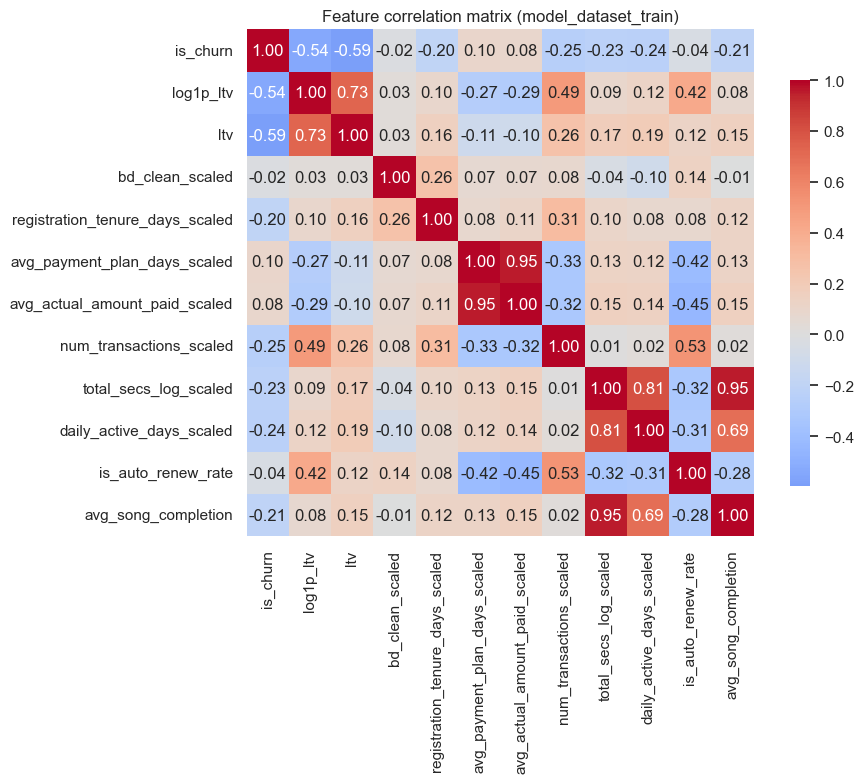

In [10]:
model_df = con.execute(f"select * exclude (msno) from '{p('model_dataset_train')}'").df()

nominal_cols = ["city_enc", "gender_enc", "registered_via_enc", "payment_method_id_enc"]
corr_cols = [c for c in model_df.columns if c not in nominal_cols]

corr = model_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Feature correlation matrix (model_dataset_train)")
fig.tight_layout()

### Distribution of every variable in the engineered table

Nominal-encoded categoricals (and the binary `is_churn` target) as count plots; everything else as histograms.

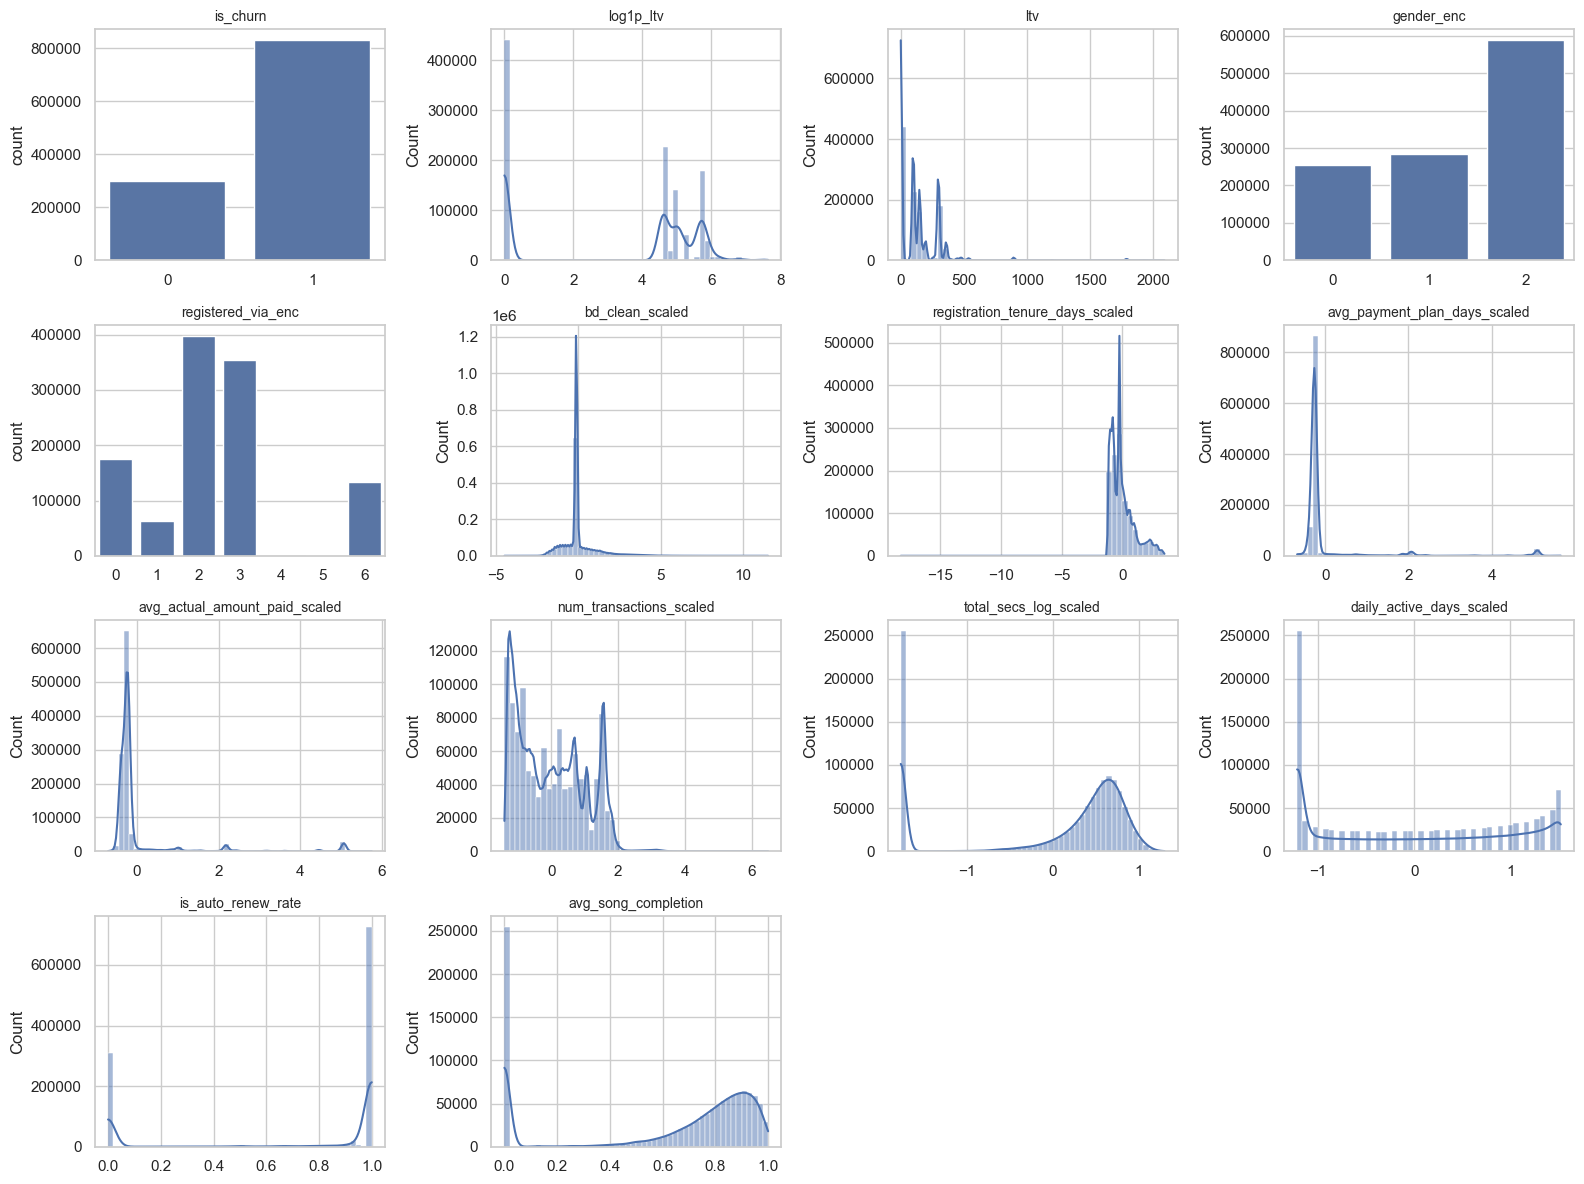

In [11]:
wide_cat_cols = ["city_enc", "payment_method_id_enc"]
count_cols = ["is_churn", "gender_enc", "registered_via_enc"]

cols = [c for c in model_df.columns if c not in wide_cat_cols]
ncols = 4
nrows = -(-len(cols) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    if col in count_cols:
        sns.countplot(x=model_df[col], ax=ax)
    else:
        sns.histplot(model_df[col], bins=50, kde=True, ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")

for ax in axes[len(cols):]:
    ax.axis("off")

fig.tight_layout()

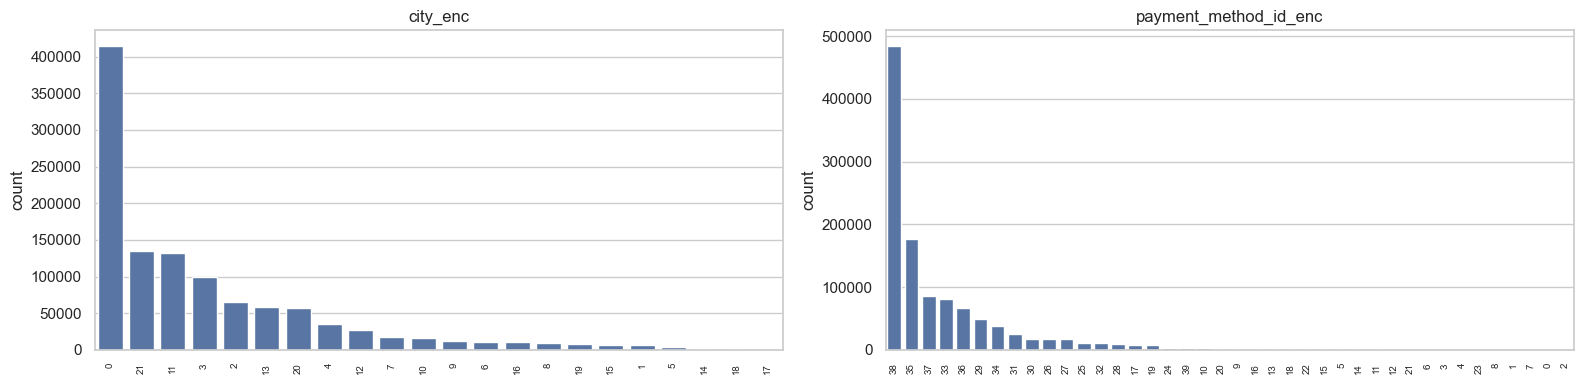

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, col in zip(axes, wide_cat_cols):
    order = model_df[col].value_counts().index
    sns.countplot(x=model_df[col], order=order, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=90, labelsize=7)

fig.tight_layout()

### Spikes worth flagging

Almost every variable has a single dominant spike rather than a smooth distribution:

- **`gender_enc`**: 60.5% of users are `unknown` (gender never provided) — consistent with the ~65% missing rate seen in raw `members`.
- **`bd_clean_scaled`**: 65.2% sit in one narrow bin around 0 — this is the imputed value standing in for missing/invalid `bd`, not a real age cluster.
- **`city_enc`**: 45.8% are a single city code (`city=1`) — one city dominates the whole user base.
- **`registered_via_enc`**: 48.6% registered via one channel (`registered_via=7`).
- **`payment_method_id_enc`**: 56.0% used a single payment method (`payment_method_id=41`).
- **`avg_payment_plan_days_scaled`**: 87.5% fall in one bin — nearly everyone is on the same plan length (the standard ~30-day plan).
- **`avg_actual_amount_paid_scaled`**: 54.6% fall in one bin — one price point dominates payments.
- **`is_auto_renew_rate`**: 79.6% sit at ~0.98–1.0 — most users have auto-renew on essentially all the time, matching it being the strongest churn predictor found earlier.
- **`log1p_ltv` / `ltv`**: 38.3% cluster around ltv ≈ 190–215 TWD — the standard monthly price acts as a floor for most users' 2-month LTV.
- **`total_secs_log_scaled`**, **`daily_active_days_scaled`**, **`avg_song_completion`**: each has ~25% of mass at/near its minimum value — a quarter of users show near-zero listening engagement in the window, matching the 22% of `train_v2` users with no `user_logs_v2` rows at all noted above.

Takeaway: several of these "spikes" are missing-value/imputation artifacts (`gender_enc`, `bd_clean_scaled`) rather than genuine behavioral clusters, so they should be treated as a "no data" flag rather than a real category when interpreting the model.

`user_logs.parquet` covers 2015-01-01 through 2017-02-28 across 5.2M users in 392M rows. duckdb aggregates it directly off disk in a few seconds without loading it into pandas.

**Data quality issue:** `total_secs` has corrupted extreme values in a small fraction of rows — min/max are around ±9.2e15 (looks like an int64 sentinel/overflow artifact from the original data pipeline), and ~62K rows are negative / ~143K rows exceed 86,400 seconds (a day) out of 392M total (~0.05%). Any per-user aggregation of `total_secs` should clip or filter these before use.

## Survival analysis: time-to-churn (Kaplan-Meier)

The sections above treat churn as a single point-in-time rate (e.g. "~9% churn" in `train_v2`, computed on one fixed snapshot window). This section instead estimates a full survival curve — `S(t) = P(still an active subscriber after t days)` — using every paying user's real transaction history, not just one snapshot.

**Duration/event construction**: for every user with at least one real (`actual_amount_paid > 0`) transaction, `duration_days` = days from their first paid transaction to their last-ever `membership_expire_date`. `event_churned = 1` if that expiry is far enough in the past (30+ days before the data ends on 2017-02-28) to be sure no renewal followed; otherwise `event_churned = 0` (right-censored — they may still renew after the data cuts off, so we can't call it churn yet). This is the same free-trial-exclusion and censoring logic as `02_Feature_Engineering.ipynb`'s survivorship-bias fix, just without that pipeline's extra 59-day LTV-buffer requirement — Kaplan-Meier only needs the 30-day churn-confirmation window, so it can use the *entire* paying population instead of restricting to cycles ending before Dec 2016.

**Data quality fix**: ~0.68% of real transactions (mostly `is_cancel=1` rows) carry a corrupted/reset `membership_expire_date` — including a literal `1970-01-01` sentinel value in some cases, i.e. *before* the transaction that produced it. These are excluded from the "last cycle" calculation (`expire_dt >= txn_dt` guard) so they can't masquerade as someone's most recent subscription cycle.

In [13]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

con.execute(f"""
    create or replace temp table txn_km as
    select *,
           strptime(cast(transaction_date as varchar), '%Y%m%d')::date as txn_dt,
           strptime(cast(membership_expire_date as varchar), '%Y%m%d')::date as expire_dt
    from '{p("transactions")}'
    where actual_amount_paid > 0
""")

survival_df = con.execute("""
    with valid_expiry as (
        select msno, expire_dt from txn_km where expire_dt >= txn_dt
    )
    select t.msno,
           min(t.txn_dt) as start_dt,
           max(v.expire_dt) as last_expire_dt,
           date_diff('day', min(t.txn_dt), max(v.expire_dt)) as duration_days,
           case when max(v.expire_dt) + interval 30 day <= date '2017-02-28' then 1 else 0 end as event_churned
    from txn_km t
    join valid_expiry v using (msno)
    group by t.msno
""").df()

print(f"paying users: {len(survival_df):,}")
print(f"event (confirmed churn) rate: {survival_df['event_churned'].mean():.3f}")
print(f"censored (still possibly active): {1 - survival_df['event_churned'].mean():.3f}")

paying users: 1,734,274
event (confirmed churn) rate: 0.375
censored (still possibly active): 0.625


median survival time: inf days


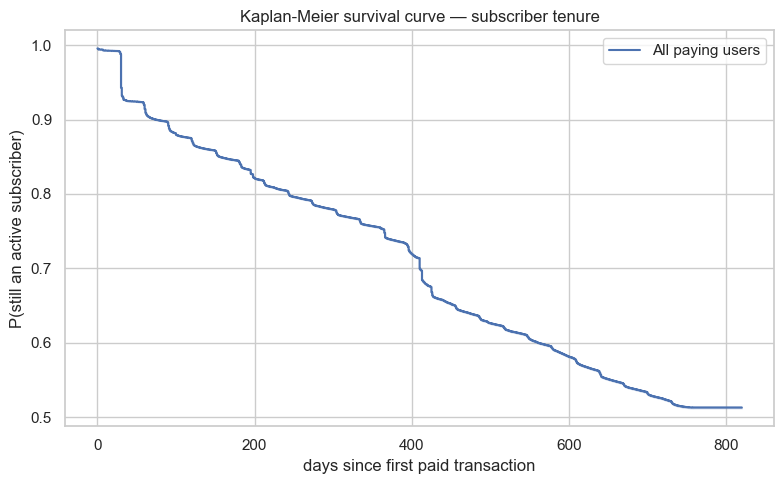

In [14]:
kmf = KaplanMeierFitter()
kmf.fit(survival_df["duration_days"], event_observed=survival_df["event_churned"], label="All paying users")

fig, ax = plt.subplots(figsize=(8, 5))
kmf.plot_survival_function(ax=ax)
ax.set_xlabel("days since first paid transaction")
ax.set_ylabel("P(still an active subscriber)")
ax.set_title("Kaplan-Meier survival curve — subscriber tenure")
fig.tight_layout()

print(f"median survival time: {kmf.median_survival_time_:.0f} days")

### Survival by auto-renew status

Splits users by their *latest* transaction's `is_auto_renew` flag, mirroring the strongest signal already found in the point-in-time analysis above. A log-rank test checks whether the two curves are statistically distinguishable.

log-rank test p-value: 0.00e+00


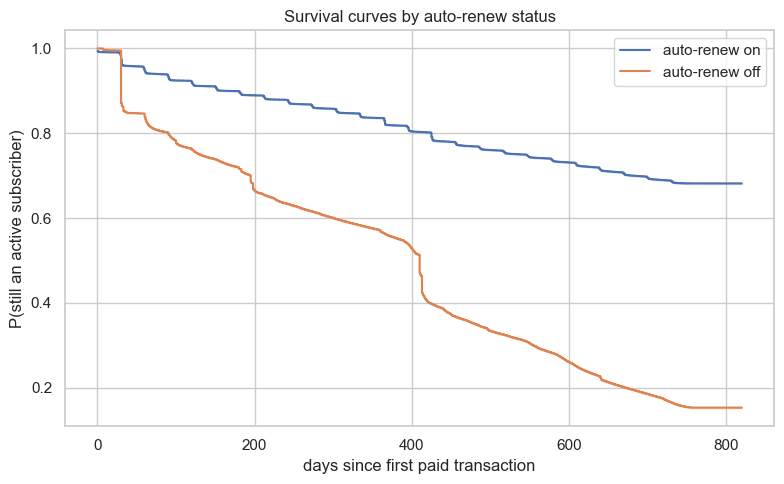

In [15]:
latest_auto_renew = con.execute("""
    select msno, is_auto_renew from (
        select msno, is_auto_renew, row_number() over (partition by msno order by txn_dt desc) rn
        from txn_km
    ) where rn = 1
""").df()

survival_df = survival_df.merge(latest_auto_renew, on="msno")

fig, ax = plt.subplots(figsize=(8, 5))
for val, label in [(1, "auto-renew on"), (0, "auto-renew off")]:
    mask = survival_df["is_auto_renew"] == val
    KaplanMeierFitter().fit(
        survival_df.loc[mask, "duration_days"],
        event_observed=survival_df.loc[mask, "event_churned"],
        label=label,
    ).plot_survival_function(ax=ax)
ax.set_xlabel("days since first paid transaction")
ax.set_ylabel("P(still an active subscriber)")
ax.set_title("Survival curves by auto-renew status")
fig.tight_layout()

group_on = survival_df[survival_df.is_auto_renew == 1]
group_off = survival_df[survival_df.is_auto_renew == 0]
result = logrank_test(
    group_on["duration_days"], group_off["duration_days"],
    event_observed_A=group_on["event_churned"], event_observed_B=group_off["event_churned"],
)
print(f"log-rank test p-value: {result.p_value:.2e}")

### Reading the curve

Overall survival: **94.3%** at 30 days, **89.2%** at 90 days, **84.3%** at 6 months, **74.8%** at 1 year, **52.1%** at 2 years. The auto-renew split is highly significant (log-rank p ≈ 0), consistent with it being the single strongest predictor found throughout this notebook.

**Why this doesn't match either of the two "churn rate" numbers already computed** (~9% in `train_v2`, ~74% in `02_Feature_Engineering.ipynb`'s modeling population) — this uses a third, different population altogether:
- `train_v2`'s ~9% only includes users who *survived* to one fixed snapshot window (survivorship bias — see project discussion).
- `02`'s ~74% only includes users whose last cycle had a *confirmable* outcome by Dec 2016, leaving 59 future days of runway to check.
- **This curve uses every paying user's actual last cycle**, however recent — so a large share (62%) are still open/**censored**: their last transaction is too close to the Feb 2017 data boundary to know yet whether they'll renew. That's also why the median survival time comes back as `inf` — the curve is still at 52% at the longest observed duration (820 days) and never gets confirmed below 50%, because roughly 75% of users with over a year of tenure are still censored (ongoing), not confirmed churned.

None of these three numbers is "wrong" — they're answering different questions (point-in-time snapshot rate vs. per-cycle non-renewal rate vs. full time-to-event curve). The survival curve is the most complete picture, but it's also the reason a single "churn rate" is inherently ambiguous for this kind of data without saying which population and time horizon it refers to.

## Corrected churn rates (post survivorship-bias-fix)

Redoes the demographic and subscription-behavior breakdowns above, but on the corrected population instead of `train_v2`: every paying user's own last *confirmable* cycle (same per-user reference-date methodology as `02_Feature_Engineering.ipynb`, including the `expire_dt >= txn_dt` data-quality fix from the survival analysis above).

In [16]:
con.execute("""
    create or replace temp table ref_dates_corrected as
    with valid_expiry as (
        select msno, expire_dt from txn_km where expire_dt >= txn_dt
    )
    select msno, max(expire_dt) as ref_date
    from valid_expiry
    where expire_dt <= date '2016-12-31'
    group by msno
""")

con.execute("""
    create or replace temp table churn_corrected as
    select r.msno, r.ref_date,
           case when exists (
               select 1 from txn_km t
               where t.msno = r.msno and t.txn_dt > r.ref_date and t.txn_dt <= r.ref_date + interval 30 day
           ) then 0 else 1 end as is_churn
    from ref_dates_corrected r
""")

con.execute("""
    create or replace temp table latest_txn_corrected as
    select msno, is_auto_renew, is_cancel, payment_plan_days from (
        select t.msno, t.is_auto_renew, t.is_cancel, t.payment_plan_days,
               row_number() over (partition by t.msno order by t.txn_dt desc) rn
        from txn_km t join ref_dates_corrected r using (msno)
        where t.txn_dt <= r.ref_date
    ) where rn = 1
""")

overall = con.execute("select avg(is_churn)*100 churn_pct, count(*) n from churn_corrected").df()
print("Overall corrected churn rate:")
display(overall)

Overall corrected churn rate:


,churn_pct,n
0,74.289767,1606796


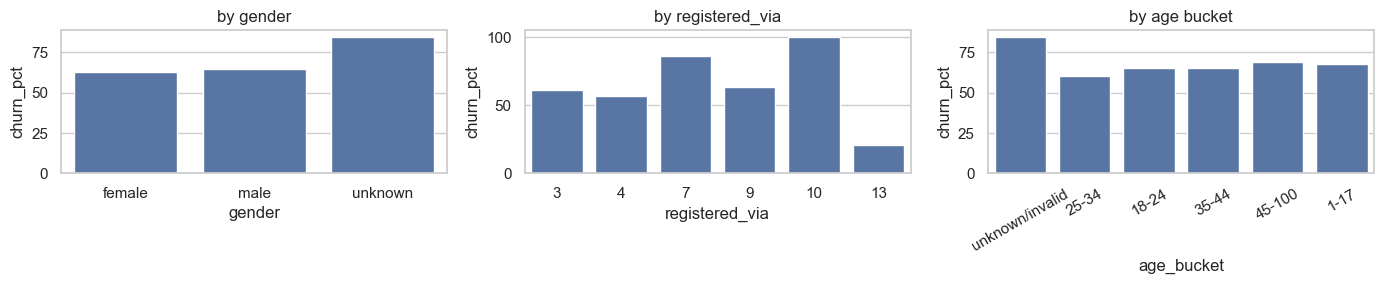

In [17]:
churn_by_gender_v2 = con.execute(f"""
    select coalesce(m.gender, 'unknown') gender, count(*) n, avg(c.is_churn) * 100 churn_pct
    from churn_corrected c
    left join '{p('members')}' m using (msno)
    group by 1
""").df()

churn_by_registered_via_v2 = con.execute(f"""
    select m.registered_via, count(*) n, avg(c.is_churn) * 100 churn_pct
    from churn_corrected c
    left join '{p('members')}' m using (msno)
    group by 1 order by n desc limit 8
""").df()

churn_by_age_v2 = con.execute(f"""
    select case when m.bd between 1 and 17 then '1-17'
                when m.bd between 18 and 24 then '18-24'
                when m.bd between 25 and 34 then '25-34'
                when m.bd between 35 and 44 then '35-44'
                when m.bd between 45 and 100 then '45-100'
                else 'unknown/invalid' end age_bucket,
           count(*) n, avg(c.is_churn) * 100 churn_pct
    from churn_corrected c
    left join '{p('members')}' m using (msno)
    group by 1 order by n desc
""").df()

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
sns.barplot(data=churn_by_gender_v2, x="gender", y="churn_pct", ax=axes[0])
sns.barplot(data=churn_by_registered_via_v2, x="registered_via", y="churn_pct", ax=axes[1])
sns.barplot(data=churn_by_age_v2, x="age_bucket", y="churn_pct", ax=axes[2])
axes[2].tick_params(axis="x", rotation=30)
for ax, title in zip(axes, ["by gender", "by registered_via", "by age bucket"]):
    ax.set_title(title)
fig.tight_layout()

,is_auto_renew,is_cancel,n,churn_pct
0,0,0,474343,79.944260
1,0,1,1,100.000000
2,1,0,869552,64.206051
3,1,1,262900,97.439711


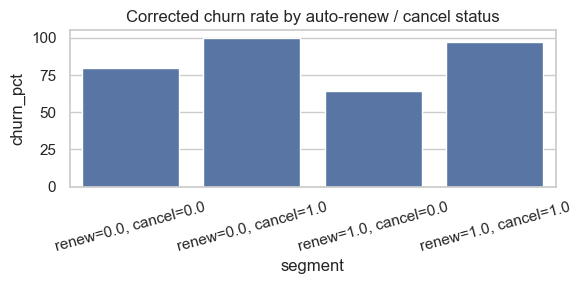

In [18]:
txn_behavior_v2 = con.execute("""
    select l.is_auto_renew, l.is_cancel, count(*) n, avg(c.is_churn) * 100 churn_pct
    from churn_corrected c
    join latest_txn_corrected l using (msno)
    group by 1, 2
    order by 1, 2
""").df()
display(txn_behavior_v2)

txn_behavior_v2["segment"] = txn_behavior_v2.apply(lambda r: f"renew={r.is_auto_renew}, cancel={r.is_cancel}", axis=1)
fig, ax = plt.subplots(figsize=(6, 3))
sns.barplot(data=txn_behavior_v2, x="segment", y="churn_pct", ax=ax)
ax.set_title("Corrected churn rate by auto-renew / cancel status")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()

### Corrected findings — and one outright reversal

Overall corrected churn: **74.3%** (1,606,796 users) — consistent with `02`'s 73.6% (the small gap is the `expire_dt >= txn_dt` data-quality fix from the survival section above, applied here for the first time to this particular breakdown).

- **Auto-renew / cancel** (direction unchanged, only magnitude): `renew=0,cancel=0` **79.9%** churn, `renew=1,cancel=0` **64.2%**, `renew=1,cancel=1` **97.4%**. Auto-renew is still protective and still the strongest single signal — just against a much higher baseline than the old 30.6%/1.8% figures implied.
- **`registered_via` — direction reverses.** Old (`train_v2`, biased): channel 7 churns *least* (4.5%), channel 4 churns *most* (23%). Corrected: channel 7 churns *most* (**86.0%**), channel 4 churns *least* among the common channels (**57.0%**), channel 13 lowest overall (**21.2%**, but small n). A business decision that optimized acquisition toward channel 7 because it "looked" like the best-retaining channel under the old snapshot would have been optimizing for the actual *worst*-retaining channel.
- **Gender — direction reverses.** Old: missing-gender users churn *less* (~6%) than users with a gender on file (~13-18%). Corrected: missing-gender users churn *more* (**84.2%**) than female (**62.5%**) or male (**64.4%**). Filling in a profile field looks like it was a proxy for genuine early engagement, not a coincidental correlate of an already-biased survivor population — the sign of that relationship only becomes visible once the survivorship bias is removed.

The auto-renew story survived the correction; the demographic stories did not — direction, not just magnitude, changed for two of the three breakdowns redone here. That's a stronger case for the bias fix than the raw ~9%-vs-~74% headline number alone.

## Key takeaways

- **Class balance**: the raw `train_v2` snapshot shows ~9% churn, but that's a survivorship-biased artifact of using one fixed snapshot window. The corrected population (every paying user's own last confirmable cycle) shows **~74% churn**; the full survival curve shows 94% retention at 30 days decaying to ~52% by 2 years. Which number is "the" churn rate depends entirely on which population and time horizon is meant — see the Survival Analysis and Corrected Churn Rates sections.
- **Strongest signal, and it survives the correction**: `is_auto_renew` and `is_cancel` from the latest transaction dominate everything else, both in the original `train_v2` cut (30.6% vs 1.8% churn) and the corrected one (64.2% vs 79.9%, with `cancel=1` at 97.4%). Treat `is_cancel` carefully — it may be too close to the churn definition to use as a naive feature.
- **Demographic signals reverse direction under the bias fix**: `registered_via` and gender both showed the *opposite* relationship to churn in the corrected population vs. the `train_v2` snapshot (e.g. channel 7 goes from the best-retaining channel to the worst). Don't trust point-in-time demographic breakdowns on this dataset without checking whether they hold up under the corrected population.
- **Listening activity** (`user_logs`) is a real but weaker signal in the original cut — churned users log modestly fewer active days and hours. 22% of labeled users have no logged activity at all in the final window.
- **Data quality**: `bd` (age) is valid for only ~33% of members; `total_secs` in `user_logs` has rare but extreme corrupted values that need clipping; ~0.68% of transactions (mostly `is_cancel=1`) carry a corrupted/reset `membership_expire_date` that must be excluded when reconstructing subscription cycles.